# Laboppgave 1: Sampling og frekvensinnhold

**Lab 1, PHYS116**  
**Navn:** Rapport Lab1  
**Dato:** [fyll inn dato]


## Erklæring

### Erklæring om arbeidsfordeling
*Her skriver dere kort om hvordan dere har samarbeidet i arbeidet med denne oppgaven. Husk at alle i gruppen er ansvarlig for hele besvarelsen*
Vi startet oppgaven sammen etter pre-lab. Bestemte oss for å lage en git for å samarbeide remote. Alle deltok i alle besvarelser på alle oppgaver.

### Erklæring om bruk av KI
*Se retningslinjene her: https://www.uib.no/nt/177637/bruk-av-kunstig-intelligens-ki-ved-fakultet-naturvitenskap-og-teknologi. Hvis dere har brukt KI så må dere skrive veldig kort hva dette har blitt brukt til, og hvilke verktøy dere har brukt til hva. Husk at dere som gruppe uansett er 100% ansvarlig for arbeidet dere leverer inn.*

Har CoPilot installert hvor den kommer med forslag til kode live.



## Målsetting

Beskriv kort formålet med laboratorieøvelsen og hvilke fenomener
som undersøkes. Forklar hva som studeres, for eksempel sammenhengen mellom
sampling, frekvensinnhold, FFT og aliasing.

Presenter kort problemstillingen og hva som skal undersøkes i laboppgaven.

## 1. Metode


Beskriv hvordan signalene ble generert og analysert. Presenter implementasjonen som ble brukt, og forklar hvilke parametere som ble valgt for simuleringene.

### 1.1 Referansemåling

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Valgfritt: brukes kun dersom lydavspilling testes
import sounddevice as sd

In [64]:
# Her vises et eksempel på hvordan man kommentere en funksjon i Python slik at man får hjelp når man bruker funksjonen. Dette kalles docstring og er en del av PEP 257.

def syn_sin(fk, Xk, fs, dur, tstart=0.0):
    """
    Syntetiserer et signal basert på gitte frekvenser og komplekse amplituder.

    Args:
        fk (array-like): Frekvensene til de harmoniske komponentene.
        Xk (array-like): Komplekse amplituder for de harmoniske komponentene.
        fs (float): Samplingsfrekvens.
        dur (float): Varighet av signalet i sekunder.
        tstart (float, optional): Starttid for signalet. Default er 0.

    Returns:
        tuple: En tuple som inneholder:
            - xx (numpy.ndarray): Det syntetiserte signalet.
            - tt (numpy.ndarray): Tidsvektor for signalet.
    """
    fk = np.asarray(fk, dtype=float)
    Xk = np.asarray(Xk, dtype=complex)

    N = int(round(fs * dur))
    tt = tstart + np.arange(N) / fs

    amplitudes = np.abs(Xk)[:, None]
    phases = np.angle(Xk)[:, None]
    frequencies = fk[:, None]

    xx = np.sum( amplitudes * np.cos(2 * np.pi * frequencies * tt + phases), axis=0, )

    return xx, tt

In [65]:
# Oppgave: Lag tilsvarende kommentar som det er gjort for syn_sin()

def amplitude_spectrum(signal, fs):
    """
    Beregner amplitudespekteret til et signal ved hjelp av FFT.

    Args:
        signal (array): Inputsignalet som skal analysers
        fs (float): Samplingsfrekvensen
    Returns:
        tuple: En tuple som inneholder:
            - freq (numpy.ndarray): Frekvensene
            - amplitude (numpy.ndarray: Amplitduene).
    """    
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)

    N = len(signal)
    X = np.fft.rfft(signal)

    freq = np.fft.rfftfreq(N, d=1/fs)
    amplitude = np.abs(X) / N

    return freq, amplitude

Text(0, 0.5, 'Amplitude')

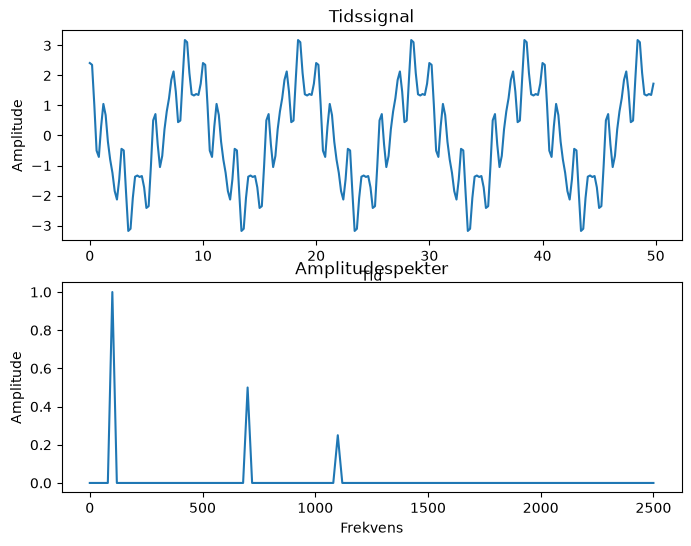

In [66]:
# Egen kode med kommentarer
#Gir variablene verdiene fra pre-labben
pi = np.pi 
fk = np.array([100, 700, 1100]) #frekvensene
Ak = np.array([2.0, 1.0, 0.5])#amplitudene
phi = np.array([pi /4, 0, -pi/2]) #fasene
Xk = Ak * np.exp(1j * phi) 
fs = 5000 #samplingsfrekvens
dur = 0.05 #måletid

# Generer signalet:
xx, tt = syn_sin(fk, Xk, fs, dur)
freq, amplitude = amplitude_spectrum(xx, fs)

#gir plass til begge figurene:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

#tidsplott og et enkeltsidig amplitudespekter 
ax1.plot(tt * 1000, xx)
ax1.set_title("Tidssignal")
ax1.set_xlabel("Tid")
ax1.set_ylabel("Amplitude")

ax2.plot(freq, amplitude)
ax2.set_title("Amplitudespekter")
ax2.set_xlabel("Frekvens")
ax2.set_ylabel("Amplitude")

In [ ]:
# kontroller at de tre frekvenskomponentene kan identifiseres, og sammenlign amplitudene
for i in range(len(fk)):
    idx = np.argmin(np.abs(freq - fk[i]))
    print(f"f = {freq[idx]:.1f} Hz, funnet amplitude = {amplitude[idx]:.3f}, brukt amplitude = {Ak[i]:.3f}")

# avstand mellom frekvenspunktene i FFT-plottet, sammenlignet med df = 1/Tmålt
df_fft = freq[1] - freq[0]
df_teori = 1 / dur
print(f"df fra FFT: {df_fft:.2f} Hz, df = 1/Tmålt: {df_teori:.2f} Hz")



### 1.2 Aliasing av sammensatte sinuser

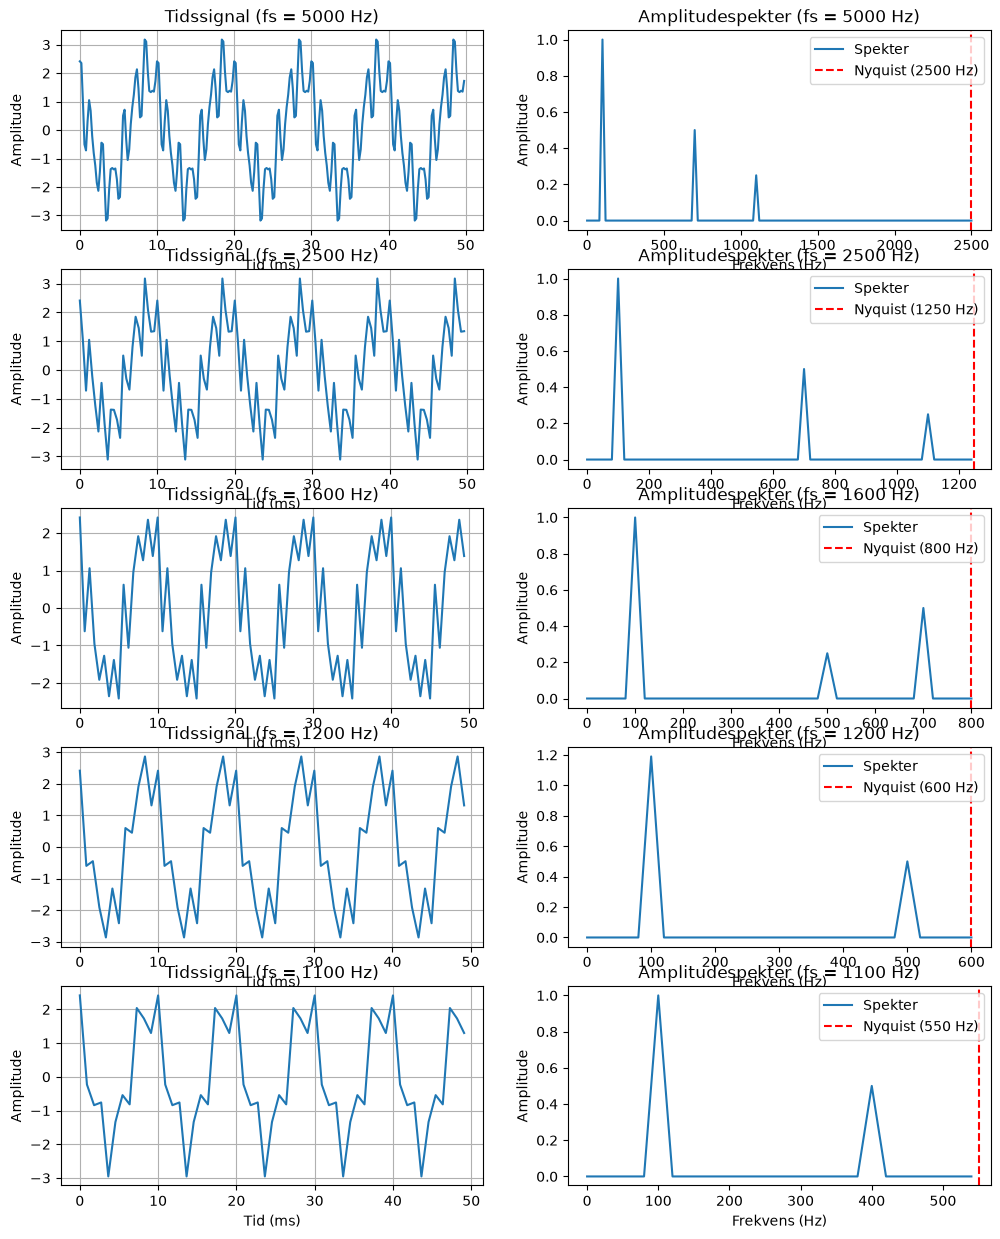

In [ ]:
#Egen kode med kommentarer
f_s = 5000, 2500, 1600, 1200, 1100

fig, axes = plt.subplots(len(f_s), 2, figsize=(12, 3 * len(f_s)))
for i, fs in enumerate(f_s):
    xx, tt = syn_sin(fk, Xk, fs, dur)
    freq, amplitude = amplitude_spectrum(xx, fs)
    ax_time = axes[i, 0]
    ax_freq = axes[i, 1]
    
    # Tidsplott
    ax_time.plot(tt * 1000, xx)
    ax_time.set_title(f"Tidssignal (fs = {fs} Hz)")
    ax_time.set_xlabel("Tid (ms)")
    ax_time.set_ylabel("Amplitude")
    ax_time.grid(True)
    
    # Frekvensplott
    ax_freq.plot(freq, amplitude, label="Spekter")
    
    #nyquistplott
    f_nyq = fs / 2
    ax_freq.axvline(f_nyq, color='r', linestyle='--', label=f'Nyquist ({f_nyq:.0f} Hz)')
    
    ax_freq.set_title(f"Amplitudespekter (fs = {fs} Hz)")
    ax_freq.set_xlabel("Frekvens (Hz)")
    ax_freq.set_ylabel("Amplitude")
    ax_freq.legend(loc='upper right')

Frekvenskomponenter som aliaseres:

Komponenter som fortsatt kan observeres direkte:

Hvordan tidsplottet endrer seg når samplingsfrekvensen reduseres:

Hva som skjer når to komponenter havner på samme frekvens i FFT-spekteret:

In [ ]:
import sounddevice as sd
signal = xx
samplingsfrekvens = fs
audio = signal / np.max(np.abs(signal))
sd.play(audio, samplingsfrekvens)
sd.wait()

### 1.3 Firkantsignal og harmoniske komponenter

In [68]:
N = ... #antall harmoniske

harmonics = ... #odde harmoniske av f0

Ak = ... #amplituden til hver harmoniske

phik = ... #fase til alle komponentene

Xk = ... #kombiner amplitude og fase

In [69]:
# Egen Kode med kommentarer

## 2. Resultater

### 2.1 Referansemåling

Presenter tidsplott og amplitudespekter for referansemålingen.


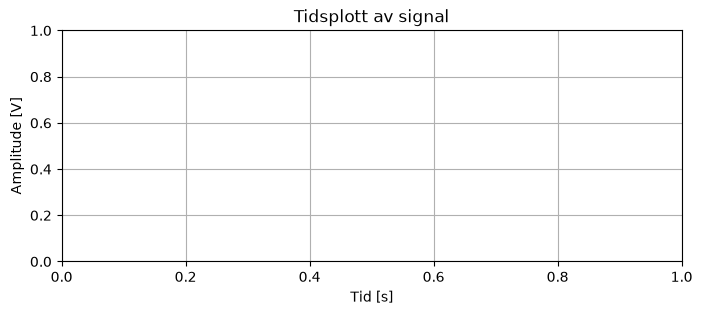

In [70]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_xlabel("Tid [s]")
ax.set_ylabel("Amplitude [V]")
ax.set_title("Tidsplott av signal")
ax.grid(True)
plt.show()

**Figurtekst:**
Forklar kort hva figuren viser og hvilke parametere som er brukt.


### 2.2 Aliasing

Presenter resultatene for de ulike samplingsfrekvensene og identifiser
observerte aliasfrekvenser.

### 2.3 Firkantsignal

Presenter tidsplott og amplitudespekter for firkantsignalet og diskuter
de observerte harmoniske komponentene.


For hver figur:
- gi en kort figurtekst,
- oppgi hvilke parametere som ble brukt,
- pek ut relevante observasjoner (for eksempel FFT-topper eller
  foldede frekvenser).

## 3. Diskusjon

Tolk resultatene og sammenlign med forventningene fra teorien.

Diskuter:
- om FFT-spekteret stemmer med de forventede frekvenskomponentene,
- når og hvorfor aliasing oppstår,
- hvordan harmoniske komponenter påvirkes av sampling,
- eventuelle avvik eller overraskende resultater.

## 4. Konklusjon

Oppsummer de viktigste resultatene fra laboppgaven.

Kommenter kort:
- hva du har lært om sampling og frekvensanalyse,
- hvilke fenomener som ble observert,
- hva som var mest utfordrende eller interessant.